In dieser Übung arbeiten wir mit dem house-prices-advanced-regression-techniques Datensatz von [Kaggle.com](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview).

Wir wollen damit sowohl den Umgang mit pandas als auch mit scikit-learn üben

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

Als erstes müssen wir den Datensatz einlesen. Hier kommt die [pd.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) Methode zum Einsatz.
Anschließend können wir zum einen einen Auschnitt des Dataframes direkt in Jupyter ausdrucken lassen, indem wir den Dataframe als letztes Argument der Zelle lassen.

In [3]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Der Dataframe hat zuviele Zeilen und sogar zuviele Spalten, um sinnvoll alle als Tabelle anzuzeigen. Drucke mit `df.columns` alle Spalten Namen aus.
Die einzelnen Spalten sind in der Datei `data_description.txt` genauer erläutert.

In [4]:
# Add code here
print(df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

Im ersten Schritt wollen wir den `SalePrice` nur basierend auf der `LotArea` vorhersagen.

Oft ist es eine gute Idee, sich ein Bild von den Daten zu machen. Als erstes machen wir einen scatterplot von diesen beiden Spalten. Dafür kann
die [df.plot.scatter](https://pandas.pydata.org/pandas-docs/version/0.25.0/reference/api/pandas.DataFrame.plot.scatter.html) Methode verwendet werden.

<Axes: title={'center': "Scatter Plot of 'Sale Price' and 'Lot Area'"}, xlabel='[LotArea]', ylabel='[SalePrice]'>

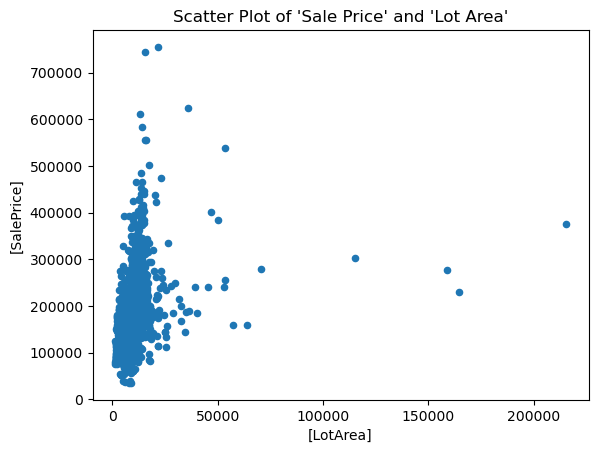

In [87]:
# Add code here

df.plot.scatter(["LotArea"], ["SalePrice"], title = "Scatter Plot of 'Sale Price' and 'Lot Area'")

Um eine Idee von der Verteilung der einzelnen Spalten zu bekommen können wir von diesen jeweils ein Histogram zeichnen. Die Methode dafür ist [df.hist](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html). Damit wollen wir nun jeweils ein Histogram von der LotArea und vom SalePrice zeichnen.

Mit der Default Einstellung ist das Ergebnis nich feingranular genug. Statt 10 sollten wir lieber 50 bins verwenden.

<Axes: title={'center': 'Histogramm of Sale Price column'}, xlabel='Sale Price in USD', ylabel='Frequency'>

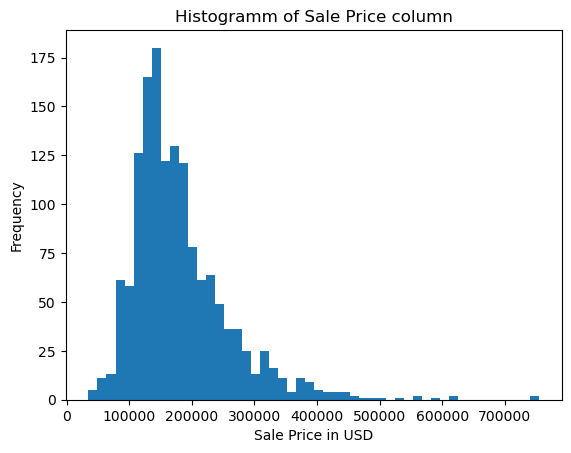

In [82]:
# Add code here
df["SalePrice"].plot.hist(title = "Histogramm of Sale Price column",
                           bins = 50,
                           xlabel = "Sale Price in USD")

<Axes: title={'center': 'Histogramm of Lot Area column'}, xlabel='Lot Area in square feet', ylabel='Frequency'>

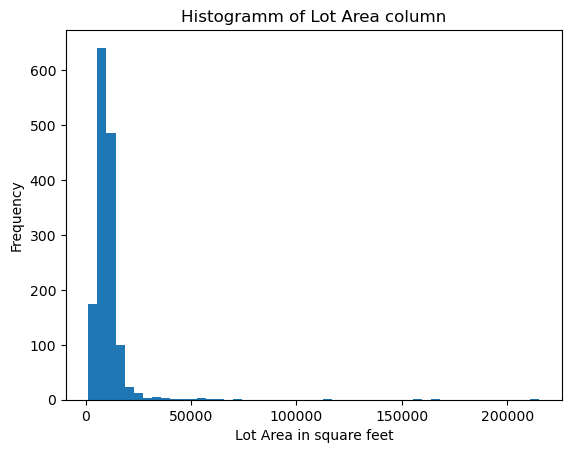

In [83]:
# Add code here
df["LotArea"].plot.hist(title = "Histogramm of Lot Area column",
                           bins = 50,
                           xlabel = "Lot Area in square feet")

Jetzt wird es Zeit, auch eine Regression zu trainineren. Die technischen Details überlassen wir dabei scikit-learn und verwenden die Klasse [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Trainiere ein Regressionsmodell mit `LotArea` als Feature und `SalePrice` als Label.

Achtung: Mit `df["ColumnName"]` können wir eine einzelne Spalte selektieren. Das Ergebnis ist eine pandas.Series. Wenn wir mehrere Columns selektieren mit `df[["ColumnName1", "ColumnName2"]]` erhalten wir einen pandas.DataFrame als Ergebnis. Für das Training sollten wir die Feature als Dataframe übergeben (schließlich braucht man in der Regel mehr als ein Feature), das Label kann eine Series sein.

In [19]:
model = LinearRegression()

# Add code here
X = pd.DataFrame(df["LotArea"])
y = df["SalePrice"]

model.fit(X,y)


<bound method RegressorMixin.score of LinearRegression()>


Von dem fertigen Model können wir uns über die Attribute `coef_` und `intercept_` die Parameter des fertigen Models geben lassen. Hier wäre die Vorhersage
`coef_ * SalePrice + intercept_`. Welche Werte haben die beiden Parameter im trainierten Modell?

In [20]:
# Add code here
print(model.coef_)

array([2.09997195])

In [22]:
# Add code here
print(model.intercept_)

158836.15189687657


Mit der Methode `predict` vom trainierten Modell können wir nun für neue Daten den Verkaufspreis vorhersagen. Welchen Preis sagt das Modell für ein Haus mit einer LotArea von 200000 voraus? Welchen für ein Haus mit wo diese 0 ist?

Achtung: `predict` geht davon aus, dass es eine List von Beispielen bekommt, wobei jedes Beispiel ein Vektor von Features ist.

In [31]:
# Add code here
print(f"Der vorhergesagten Preis für ein Haus mit LotArea = 200000 liegt bei {model.predict([[200000]])[0]} usd")

print(f"Der vorhergesagten Preis für ein Haus mit LotArea = 0 liegt bei {model.predict([[0]])[0]} usd (== intercept Wert)")

Der vorhergesagten Preis für ein Haus mit LotArea = 200000 liegt bei 578830.5422384117 usd
Der vorhergesagten Preis für ein Haus mit LotArea = 0 liegt bei 158836.15189687657 usd (== intercept Wert)


/Users/maksim/miniconda3/envs/aibi/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/maksim/miniconda3/envs/aibi/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Wenn wir `predict` nur mit einer Liste oder einem Numpy Array aufrufen, bekommen wir eine Warning, dass der Input keine validen Feature Names hat.
Durch die Verwendung von Pandas Dataframes kann scikit learn sich für jede Input Spalte merken, wie das Feature hieß. Dadurch können später Fehler durch
vertauschte Spalten vermieden werden.
Mit dem Attribut `feature_names_in_` können wir ermitteln, wie die gelernten Features heißen

In [33]:
# Add code here
print(model.feature_names_in_)

['LotArea']


Wenn wir `predict` auf unseren Input Daten aufrufen, erhalten wir für alle Inputs eine Vorhersage.

In [37]:
# Add code here
predictions = model.predict(X)

Als nächstes wollen wir uns anschauen, wie groß der Trainings Loss war. Diesen berechnen wir mit der Methode [sklearn.metrics.mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html). Als Input braucht diese die echten Labels und die Vorhersagen.

In [36]:
from sklearn.metrics import mean_squared_error

In [49]:
# Add code here
error = mean_squared_error(y_true = y, y_pred = predictions)
errors = predictions - y
print(error)

5867752122.509074


Diese Zahl ist der durchschnittliche quadierte Fehler. Um diesen besser interpretieren zu können macht es Sinn, die Wurzel (z.B. mit `np.sqrt`) davon zu
nehmen. Diese Größe nennt sich Root Mean Squared Error (RMSE). Ihre Einheit ist die gleiche, wie die vom Label (hier Dollar). Sie ist die Standardabweichung des Fehlers,
den unser Modell macht. Je größer, umso mehr liegt unser Modell daneben. Wenn die Fehler normalverteilt sind, haben dann ca. 68% der Inputs einen Fehler von weniger als dem RMSE.
Berechne nun den RMSE

In [50]:
# Add code here
rmse = np.sqrt(error)
rmse

np.float64(76601.25405310982)

Da der RMSE die Standardabweichung des Fehlers ist, können wir diesen auch berechnen, indem wir die Numpy Funktion für die Standardabweichung `np.std` auf dem Fehler (der Differenz von korrektem Wert und Vorhersage) aufrufen

In [51]:
# Add code here

std = np.std(errors)
std

np.float64(76601.25405310982)

Nun wollen wir den Fehler unseres Modells plotten. Bei linearer Regression gehen wir davon aus, dass die Fehler normalverteilt sind. Es macht Sinn, diese Annahme zu überprüfen.
Dafür plotten wir ein Histogramm (mit 50 bins)

<Axes: title={'center': 'Dispersion of the error'}, ylabel='Frequency'>

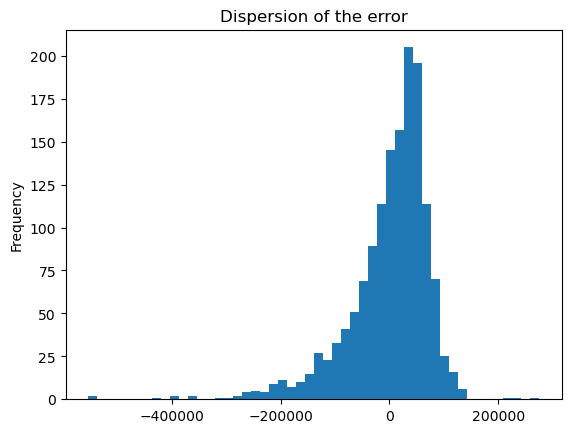

In [52]:
# Add code here

errors.plot.hist(bins = 50, title = "Dispersion of the error")

#Fehler ist tatsächlich normalverteilt

Nun wollen wir das Modell verbessern und mehr Features verwenden. Wir wollen alle Spalten nutzen, die numerische Werte haben. Ein Weg sich diese einfach zu ermitteln ist `list(df.select_dtypes(include=[np.int64, np.float64]).columns)`. Die Spalte `"Id"` macht als Feature keinen Sinn (das ist nur die fortlaufende Nummer der Beispiele aus dem Dataframe). Die Spalte `"SalePrice"` dürfen wir auch nicht als Feature verwenden (diese wollen wir ja vorhersagen).

In [54]:
feature_columns = [
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

Nicht alle Features können einfach so verwendet werden. Mit `df[feature_columns].isna().sum()` können wir für jede Spalte zählen, wieviele Einträge fehlen ("NA" sind).
Dabei sehen wir, dass zum Beispiel in der Spalte "LotFrontage" 259 Einträge fehlen.

Diese müssen wir für das Modell substituieren. Zuerst machen wir einen neuen Dataframe `features = df[feature_columns]`, der nur die gewählten feature_columns enthält.
Mit der Funktion [fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) können nun fehlende Werte substituiert werden. Wir müssen nur angeben, wie die Funktion das tun soll. Eine mögliche Strategie ist, immer 0 aufzufüllen. Das kann aber zu verzerrten Ergebnissen führen (bei der LotSize währe etwa ein Wert von 0 sicher nicht sinnvoll). Hier wollen wir fehlende Werte mit dem Durchschnittswert der jeweiligen Spalte befüllen. Dieser kann mit [mean](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html) berechnet werden.

In [ ]:
# Add code here

features_subset = df[feature_columns]
#print(f"{features_subset.isna().sum()}\n")

def get_mean_dict(df: pd.DataFrame)->dict:
    mean_dict = {}
    for feature in feature_columns:
        mean_dict[feature] = np.mean(df[feature])

    return mean_dict


values_for_na = get_mean_dict(features_subset)

features_subset = features_subset.fillna(value = values_for_na)

#print(features_subset.isna().sum())


MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
dtype: int64

MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1s

Mit diesen neuen Werten wollen wir nun eine neue Lineare Regression trainieren

In [76]:
model2 = LinearRegression()

# Add code here
X_2 = pd.DataFrame(features_subset)
y_2 = df["SalePrice"]

model2.fit(X_2,y_2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Analog zu vorhin wollen wir auch hier den RMSE berechnen und den Fehler als Histogramm plotten.

In [ ]:
# Add code here
predictions = model2.predict(X_2)
rmse = np.sqrt(mean_squared_error(y_true=y_2, y_pred=predictions))
print(rmse)

#man sieht, dass mit gestiegenem Anzahl an Features der Fehler geringer geworden ist (~ 34.330 usd)

34330.50278820362


<Axes: >

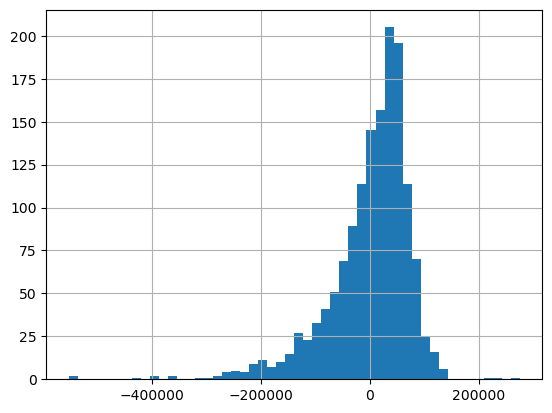

In [ ]:
# Add code here
errors = predictions - y_2

errors.hist(bins=50, title = "Dispersion of the error")

#ist auch normal verteilt

Das neue Modell können wir weiter analysieren. Für jedes Input Feature wollen wir uns ausdrucken, welchen Koeffizienten das Modell dafür gefunden hat. Hier kommen die Attribute `coef_` und `feature_names_in_` des Modells zum Einsatz. Auch die Python Funktion [zip](https://docs.python.org/3.3/library/functions.html#zip) kann hier nützlich sein.

In [86]:
# Add code here
print("Feature_Name|Coef")
for feature_name, coef in zip(model2.feature_names_in_, model2.coef_):
    print(feature_name, coef)

Feature_Name|Coef
MSSubClass -181.5943732790289
LotFrontage -56.229885162158986
LotArea 0.4300135427033974
OverallQual 17323.840427332485
OverallCond 4664.874989163515
YearBuilt 271.6503695532419
YearRemodAdd 136.0780336196552
MasVnrArea 31.46392976547435
BsmtFinSF1 10.000856864319214
BsmtFinSF2 -0.9148638630972269
BsmtUnfSF 0.11323660941381015
TotalBsmtSF 9.19922960669013
1stFlrSF 18.058293255625284
2ndFlrSF 18.101566288721557
LowQualFinSF -5.268174125624356
GrLivArea 30.891685419780163
BsmtFullBath 9359.129504575523
BsmtHalfBath 2037.7219211253946
FullBath 3448.2687996502586
HalfBath -1899.583571373389
BedroomAbvGr -10095.995121871701
KitchenAbvGr -12209.693398814383
TotRmsAbvGrd 5063.413264687474
Fireplaces 3966.4304419509226
GarageYrBlt 121.15469159344029
GarageCars 11234.641020581259
GarageArea -4.236467890625698
WoodDeckSF 24.021554197210694
OpenPorchSF -2.871141962082964
EnclosedPorch 11.82679419494411
3SsnPorch 20.496172611996954
ScreenPorch 56.004668382515604
PoolArea -29.0824